In [2]:
# essential package imports
import pandas as pd

In [3]:
# read in data file as pandas dataframe (~9 min on macbook)
df = pd.read_csv('/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/lexical_master.csv')

# User Frequency Analaysis

# Posting Frequency Distribution Analysis
Examine the skew of speaker post-count distribution to motivate bin selection strategy.

In [9]:
from userfreq_analysis import summarize_freq_distribution, plot_freq_distribution, diagnose_quartile_bins

summarize_freq_distribution(df)

=== Speaker Post-Count Distribution ===
  N speakers      :    3,915,835
  Mean            :         9.93
  Median          :         2.00
  Std dev         :       120.05
  Skewness        :       114.35  (>1 = right-skewed)
  Excess kurtosis :     23358.19
  Min / Max       :      1 / 46,231

=== Percentiles ===
  P    1  :         1 posts
  P    5  :         1 posts
  P   10  :         1 posts
  P   25  :         1 posts
  P   50  :         2 posts
  P   75  :         4 posts
  P   90  :        12 posts
  P   95  :        26 posts
  P   99  :       122 posts
  P 99.9  :       809 posts

=== Low-Count Speaker Breakdown ===
  <=  1 post(s)  : 45.7% of speakers
  <=  2 post(s)  : 61.4% of speakers
  <=  3 post(s)  : 70.0% of speakers
  <=  5 post(s)  : 79.2% of speakers
  <= 10 post(s)  : 88.3% of speakers


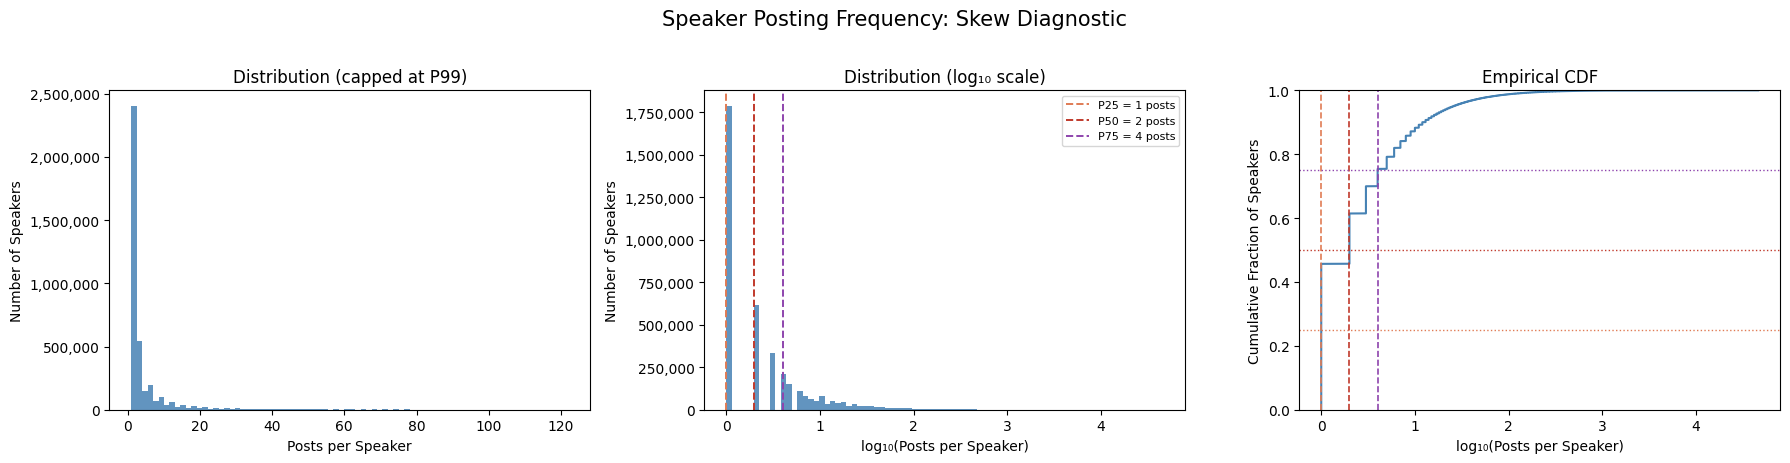

In [5]:
plot_freq_distribution(df)

In [6]:
diagnose_quartile_bins(df)

Requested bins : 4
Bins produced  : 3  <-- duplicate edges dropped
Bin edges      : [1, 2, 4, 46231]

  Q1: [   1,      2] posts  →   2,405,869 speakers  (61.4%)
  Q2: [   2,      4] posts  →     546,303 speakers  (14.0%)
  Q3: [   4,  46231] posts  →     963,663 speakers  (24.6%)


## Data Prep

In [10]:
from userfreq_analysis import assign_freq_quartiles, prepare_panel

# For Analysis 2 (all speakers, no temporal filter)
df_q = assign_freq_quartiles(df)

# For Analysis 1 (speakers with >= min_obs monthly rows only)
panel = prepare_panel(df, min_obs=6)

Retained 765,172 / 3,915,836 speakers (19.5%) with >= 6 monthly observations.


## Analysis 1

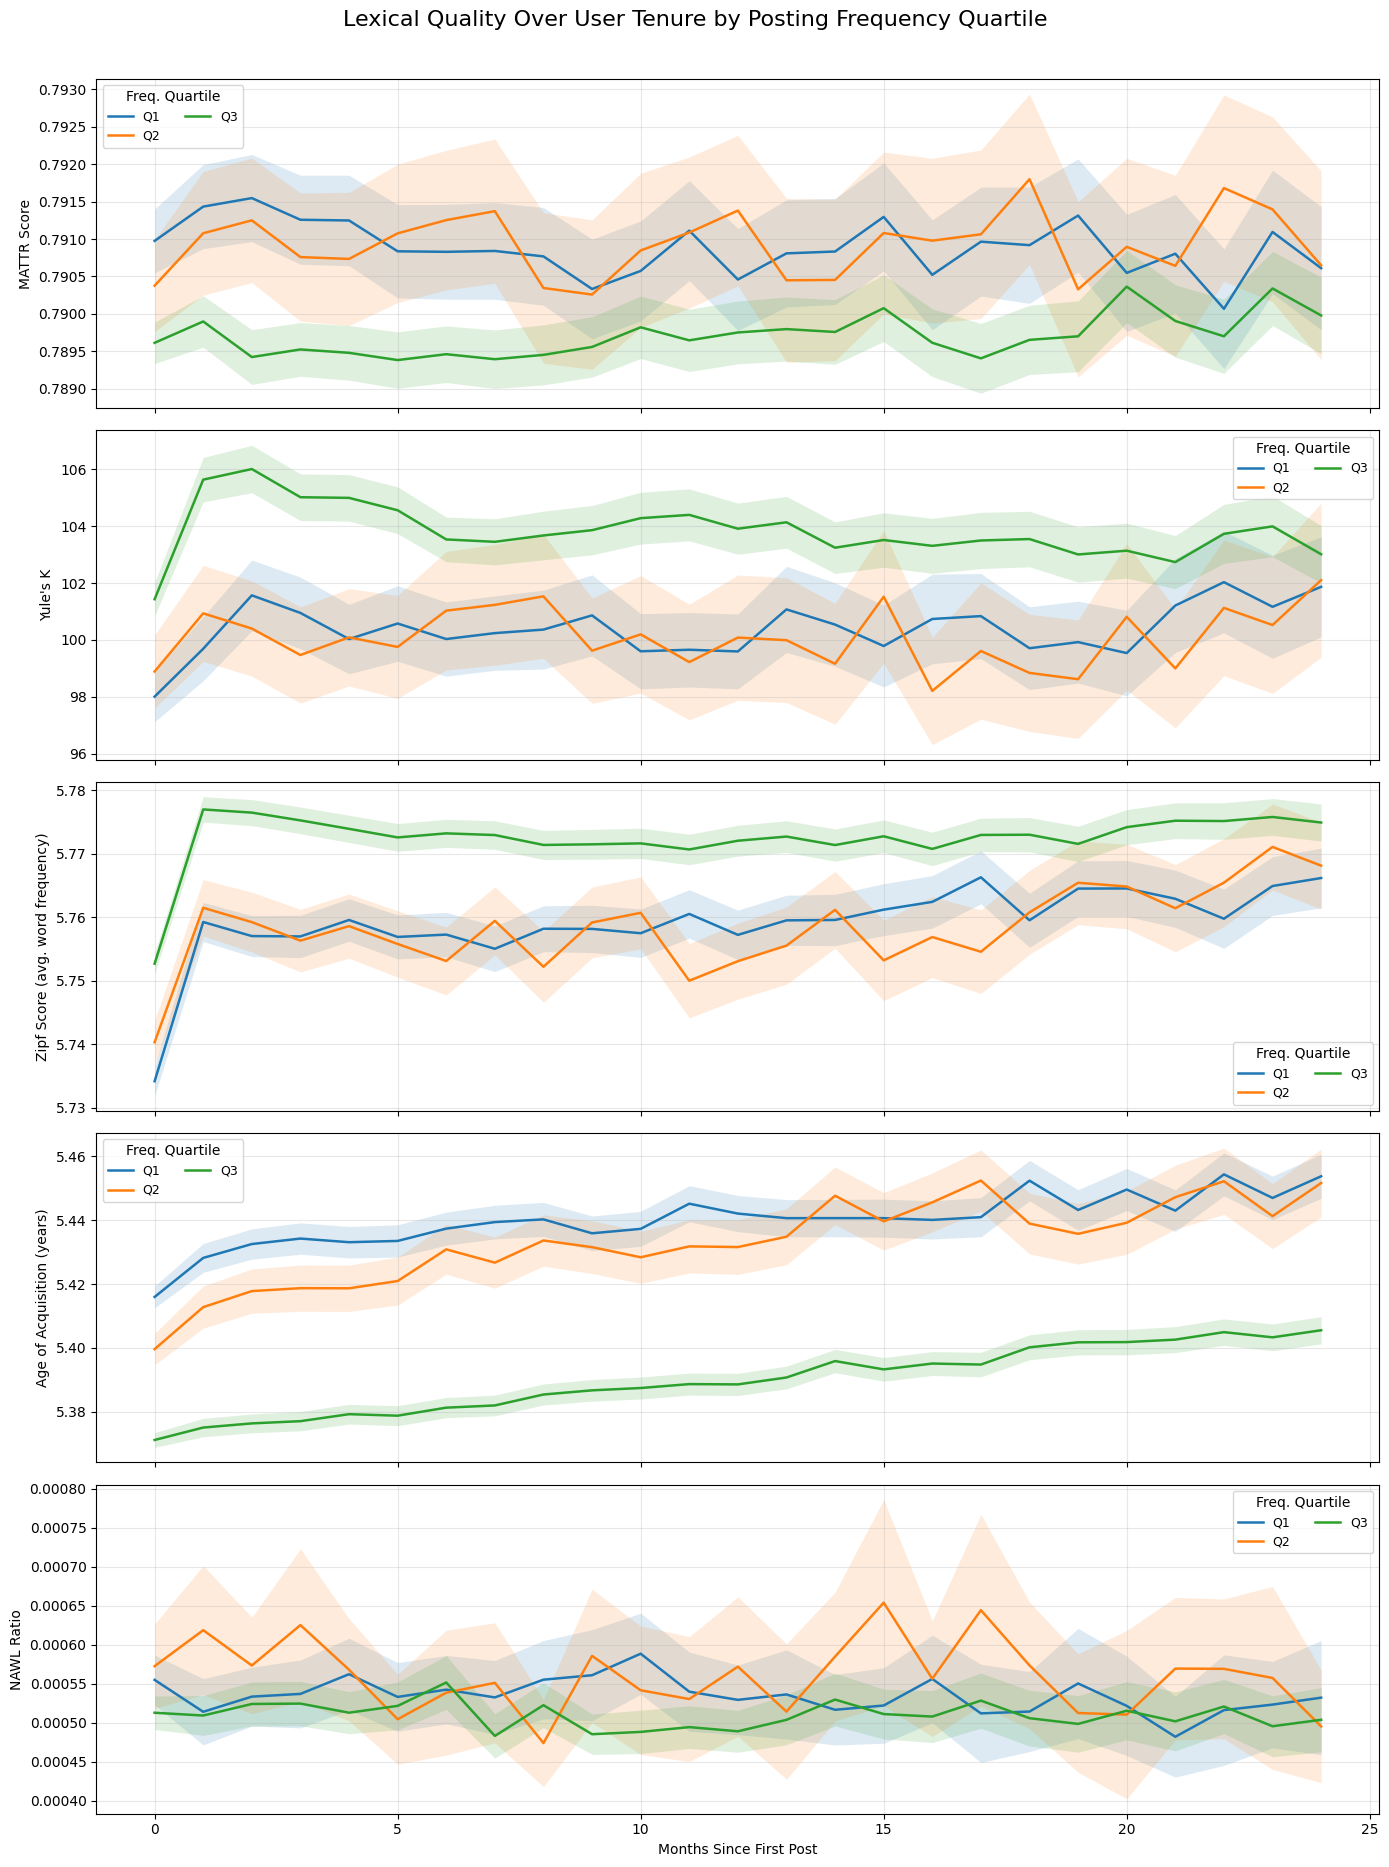

In [11]:
from userfreq_analysis import plot_quality_over_relative_time

plot_quality_over_relative_time(panel, max_relative_month=24)

## Analysis 2

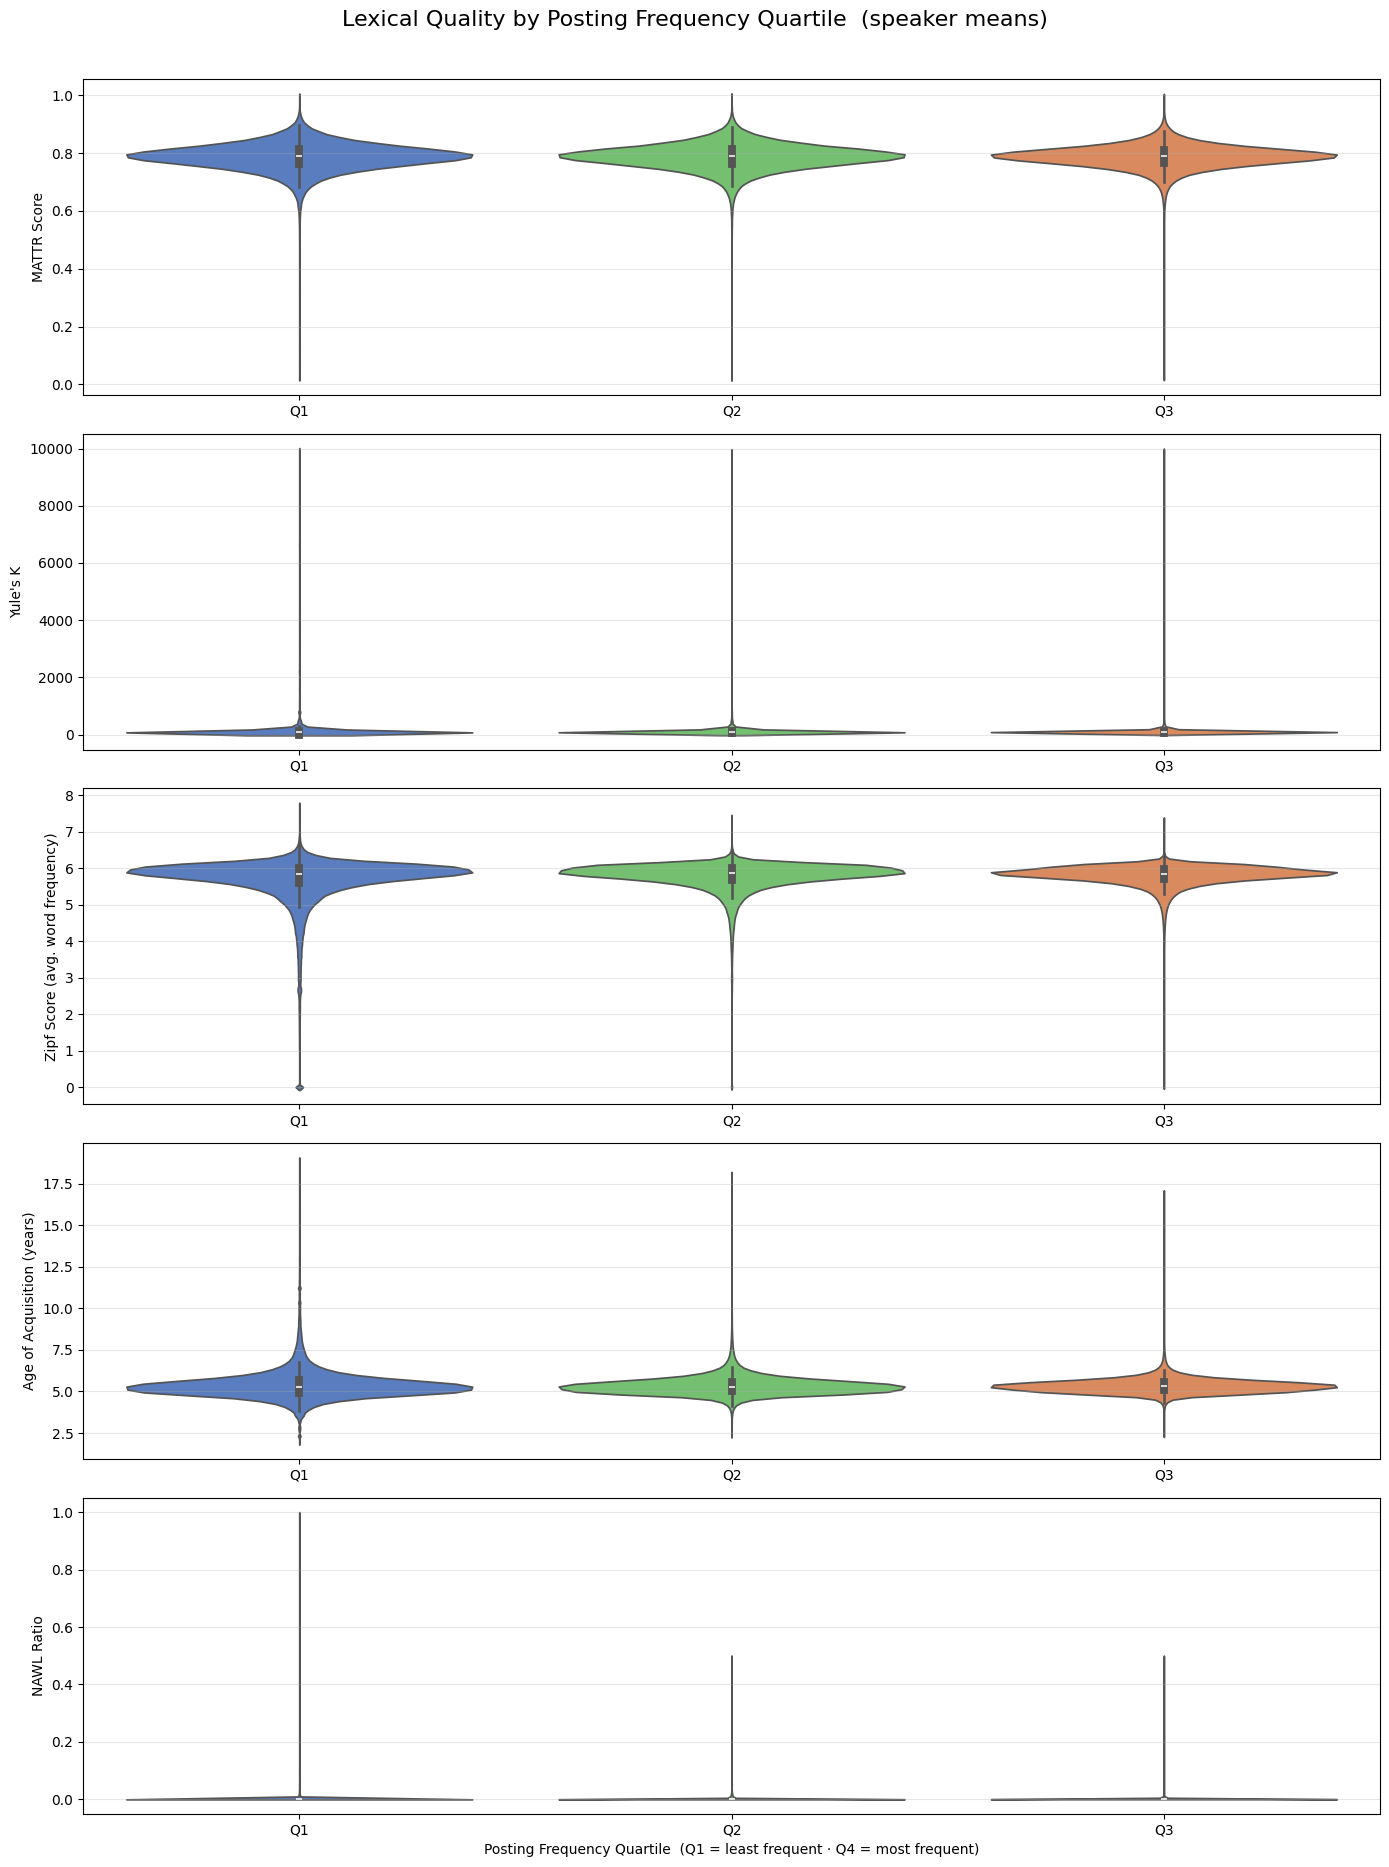

In [12]:
from userfreq_analysis import plot_quality_by_freq_quartile, run_freq_quartile_tests

plot_quality_by_freq_quartile(df_q, kind='violin')   # or kind='box'
results = run_freq_quartile_tests(df_q)

# Temporal Analysis

In [ ]:
df2 = pd.read_csv('/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/lexical_temporal.csv')